## A/B тест
Данный проект создан для лучшего усвоения и демонстрации знаний по проведению A/B тестирования. Полный цикл A/B тестирования требует продукт/сайт и пользователи, которые им пользуются, что сложно реализовать в учебном проекте.

Я взял датасет с уже разделенными на выборки наблюдениями и подсчитанными для каждого метриками. Такие данные осталось только изучить, подготовить, провести статистический тест и интерпретировать результаты. НО в этом проекте я постараюсь расписать или даже «реконструировать» каждый этап A/B тестирования.


## Этапы A/B теста
1. Гипотеза
2. Подготовка эксперимента
3. Анализ результатов


## 1. Гипотеза
Представим самый простой вариант: у нас есть сайт, на котором продаются товары для дома, и мы хотим увеличить количество покупок. Проанализировав имеющиеся данные, мы видим, что конверсия в добавление товаров в корзину имеет низкое значение, и решаем, что для достижения увеличения продаж нужно повысить этот показатель. Для этого команда разработчиков создала новый дизайн страницы, и, чтобы проверить, изменит ли новый дизайн ситуацию, мы решили провести A/B-тест.

Итак, **цель** — `увеличить количество покупок`, **метрика** — `конверсия в добавление в корзину


Чтобы полностью сформулировать продуктовую гипотезу по методу SMART (S — specific — конкретность, M — measurable — измеримость, A — achievable — достижимость, A — achievable — достижимость, R — reasonable — релевантность, T — time-bound — ограниченность по времени), нам не хватает значений конверсии до проведения теста и времени проведения теста. Для этого обратимся к имеющимся данным по уже результатам тестирования, потому что других данных у нас нет :).
### Продуктовая гипотеза
Новая страница увеличит конверсию в добавление в корзину на `X` процентных пункта для пользователей сайта в течении `Y` дней.


### Статистическая гипотеза
$H_0: Conversion_1 = Conversion_2$

$H_1: Conversion_1 > Conversion_2$`

.Нет необходимости проверять двустороннюю гипотезу, так как нам важно только повышение метрикиным.

## 2. Подготовка экперимента
В этот пункт входит: 1 - определенние кол-ва необходимого минимальное количество наблюдений для проведения эксперимента,2 - определение значимости и мощности,3 - разделение пользоватлеей на группы.

Значимость и мощность будут стандартные: $\alpha = 5\% $ и $\beta = 20\% $

В самом датасате пользователи уже разделены на группы.

In [477]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats 
from statsmodels.stats.proportion import proportions_ztest, proportion_confint



In [205]:
df = pd.read_csv('ab_data.csv',parse_dates=['timestamp'])
df

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1
...,...,...,...,...,...
294473,751197,2017-01-03 22:28:38.630509,control,old_page,0
294474,945152,2017-01-12 00:51:57.078372,control,old_page,0
294475,734608,2017-01-22 11:45:03.439544,control,old_page,0
294476,697314,2017-01-15 01:20:28.957438,control,old_page,0


In [207]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   user_id       294478 non-null  int64         
 1   timestamp     294478 non-null  datetime64[ns]
 2   group         294478 non-null  object        
 3   landing_page  294478 non-null  object        
 4   converted     294478 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 11.2+ MB


In [209]:
df.describe()

,user_id,timestamp,converted
count,294478.000000,294478,294478.000000
mean,787974.124733,2017-01-13 13:40:10.474213376,0.119659
min,630000.000000,2017-01-02 13:42:05.378582,0.000000
25%,709032.250000,2017-01-08 02:06:48.649925120,0.000000
50%,787933.500000,2017-01-13 13:21:07.016475904,0.000000
75%,866911.750000,2017-01-19 01:43:51.611873792,0.000000
max,945999.000000,2017-01-24 13:41:54.460509,1.000000
std,91210.823776,NaN,0.324563


In [211]:
pd.crosstab(df['group'],df['landing_page']) # Видим пересечения тестовой и контрольной группы

landing_page,new_page,old_page
group,,
control,1928,145274
treatment,145311,1965


In [213]:
sessions_counts = df['user_id'].value_counts()
sessions_counts[sessions_counts> 1] # Видим, что некоторые пользователи дублируются. Возможно это те пользователи, которые заходили и на старую и на новую страницу

user_id
805339    2
754884    2
722274    2
783176    2
898232    2
         ..
847058    2
889392    2
664150    2
835401    2
736955    2
Name: count, Length: 3894, dtype: int64

In [215]:
df = df[~(df['user_id'].isin(sessions_counts[sessions_counts > 1].index))]
df

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1
...,...,...,...,...,...
294473,751197,2017-01-03 22:28:38.630509,control,old_page,0
294474,945152,2017-01-12 00:51:57.078372,control,old_page,0
294475,734608,2017-01-22 11:45:03.439544,control,old_page,0
294476,697314,2017-01-15 01:20:28.957438,control,old_page,0


In [217]:
pd.crosstab(df['group'],df['landing_page']) # Так и есть

landing_page,new_page,old_page
group,,
control,0,143293
treatment,143397,0


Найдем старый показатель конверсии, определим на сколько мы преполагаем повысить конверсию, то есть MDE и определим количество\время нужное для проведение эксперимента

In [224]:
old_conversion = df[df['group'] == 'control']['converted'].mean()
old_conversion 

0.12017335110577627

Допустим мы хотим повысить конверсию на два процентных пункта, то есть MDE = 0.02

Число необходимых наблюдений буду считать по этой формуле
$n = 2*\sigma^2 *(z_{1-\alpha} + z_\beta) / MDE^2$

где $\sigma$ - это выборочное стандартное отклонение, 

$\alpha$ - уровень значимости(5%)

$\beta$ - мощность(20%)



In [255]:
sigma = df[df['group'] == 'control']['converted'].var()
sigma

0.1057324546656412

In [282]:
pack_size = int(2 * sigma *(scipy.stats.norm.ppf(0.95) + scipy.stats.norm.ppf(0.8))**2 /0.02 ** 2) + 1
pack_size

3269

Посмотрим среднее кол-во пользователей за день

In [292]:
avg_users_per_day = int(df.groupby(pd.Grouper(key='timestamp', axis=0, 
                      freq='d'))['user_id'].nunique().mean()) 
avg_users_per_day

12464

Получается мы можем провести тест за день :)

## Полные гипотезы
### Продуктовая гипотеза
Новая страница увеличит конверсию в добавление в корзину на `2` процентных пункта для пользователей сайта в течении `1` дня.


### Статистическая гипотеза
$H_0: Conversion_1 = Conversion_2$

$H_1: Conversion_1 > Conversion_2$


Объем выборки в датасете больше, чем нам нужно возьмем в случайно порядке нужное нам количество наблюдений для каждой группы

In [397]:
old_ver = df[df['group'] == 'control']
new_ver = df[df['group'] == 'treatment']

old_sample = old_ver.sample(n=pack_size, random_state=17)
new_sample = new_ver.sample(n=pack_size, random_state=17)

ab_test = pd.concat([old_sample, new_sample], axis=0)
ab_test.reset_index(drop=True, inplace=True)
ab_test

,user_id,timestamp,group,landing_page,converted
0,750459,2017-01-24 00:46:58.596981,control,old_page,0
1,742396,2017-01-21 12:38:07.709505,control,old_page,0
2,840639,2017-01-07 11:03:27.966245,control,old_page,0
3,714696,2017-01-10 04:59:35.428971,control,old_page,0
4,687923,2017-01-05 07:47:20.678007,control,old_page,0
...,...,...,...,...,...
6533,887507,2017-01-08 15:09:30.982316,treatment,new_page,0
6534,694248,2017-01-16 07:19:28.605799,treatment,new_page,0
6535,870868,2017-01-21 00:39:59.594499,treatment,new_page,0
6536,860130,2017-01-22 11:04:55.972103,treatment,new_page,0


In [399]:
ab_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6538 entries, 0 to 6537
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       6538 non-null   int64         
 1   timestamp     6538 non-null   datetime64[ns]
 2   group         6538 non-null   object        
 3   landing_page  6538 non-null   object        
 4   converted     6538 non-null   int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 255.5+ KB


## 3. Анализ результатов

Визуализируем результаты

In [403]:
results = ab_test.groupby('group')['converted'].agg(['mean','std'])
results

,mean,std
group,,
control,0.123891,0.329508
treatment,0.119303,0.324194


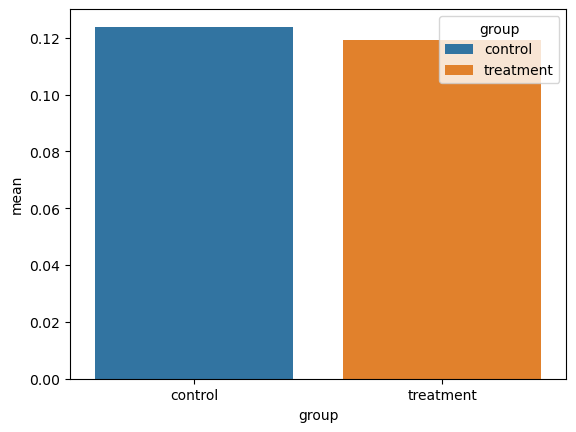

In [475]:
sns.barplot(y=results['mean'],x=results.index, hue=results.index,legend=True)
plt.show()

In [443]:
old_result = ab_test[ab_test['group'] == 'control']['converted']
new_result = ab_test[ab_test['group'] == 'treatment']['converted'].reset_index(drop=True)

In [ ]:
Ввиду асимптотической нормальности биноминального распределения(с которым мы и имеем дело), воспользуемся z-test

In [480]:
n_con = old_result.count()
n_treat = new_result.count()
successes = [old_result.sum(), new_result.sum()]
nobs = [n_con, n_treat]

z_stat, pval = proportions_ztest(successes, nobs=nobs)

print(f'Z статистика: {z_stat:.2f}')
print(f'p-value: {pval:.3f}')


Z статистика: 0.57
p-value: 0.570


p-value меньше $\alpha$(0.05)